## Topic Modelling of Stories

This notebook is organized for repeatable parameter sweeps across every dataset path already defined below.

Workflow:
1. Load one dataset with a normalized `cluster_text` column.
2. Select the three test configurations for its corpus profile (`interaction_level` or `full_text`).
3. Fit each configuration with `ClusteringTopicModel`.
4. Visualize each fit twice:
   - a static 2D UMAP coloured by HDBSCAN labels
   - an interactive Turftopic datamap plot after `OpenAIAnalyzer` names and describes the topics

Parameter choices are profile-aware:
- `interaction_level` corpora contain many short documents, so they use broader local neighbourhoods and larger HDBSCAN minimum cluster sizes.
- `full_text` corpora contain far fewer but much longer documents, so they use smaller neighbourhoods and more permissive cluster sizes.

The `human_ai_interaction_level` file stores the two sides of an exchange in separate columns (`author_1`, `author_2`), so this notebook combines them into one short exchange per row before fitting.


In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
from hdbscan import HDBSCAN
from turftopic import ClusteringTopicModel
from turftopic.analyzers import OpenAIAnalyzer
from umap import UMAP

load_dotenv()


True

In [4]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate a project root containing a data/ directory.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
NOTEBOOK_DIR = PROJECT_ROOT / "analysis" / "comparison"
ARTIFACT_DIR = NOTEBOOK_DIR / "topic_modelling_artifacts"
CLUSTER_MAP_DIR = ARTIFACT_DIR / "cluster_maps"
UMAP_DIR = ARTIFACT_DIR / "umap_plots"

for directory in [ARTIFACT_DIR, CLUSTER_MAP_DIR, UMAP_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ENCODER_NAME = "paraphrase-mpnet-base-v2"
OPENAI_ANALYZER_MODEL = "gpt-5-nano"
RANDOM_STATE = 42

DATASETS = {
    "combined_full_text": {
        "label": "Combined full text",
        "path": DATA_DIR / "combined" / "combined_data.csv",
        "profile": "full_text",
        "text_column": "full_story",
    },
    "human_ai_full_text": {
        "label": "Human-AI full text",
        "path": DATA_DIR / "human-ai" / "interim" / "stories_full_text_filtered.csv",
        "profile": "full_text",
        "text_column": "full_story",
    },
    "ai_ai_full_text": {
        "label": "AI-AI full text",
        "path": DATA_DIR / "ai-ai" / "interim" / "stories_full_text_filtered.csv",
        "profile": "full_text",
        "text_column": "full_story",
    },
    "human_human_full_text": {
        "label": "Human-Human full text",
        "path": DATA_DIR / "human-human" / "interim" / "stories_full_text_filtered.csv",
        "profile": "full_text",
        "text_column": "full_story",
    },
    "human_ai_interaction_level": {
        "label": "Human-AI interaction level",
        "path": DATA_DIR / "human-ai" / "interim" / "interaction_level_stories_filtered.csv",
        "profile": "interaction_level",
        "text_columns": ["author_1", "author_2"],
    },
    "ai_ai_interaction_level": {
        "label": "AI-AI interaction level",
        "path": DATA_DIR / "ai-ai" / "interim" / "interaction_level_stories_long_filtered.csv",
        "profile": "interaction_level",
        "text_column": "text",
    },
    "human_human_interaction_level": {
        "label": "Human-Human interaction level",
        "path": DATA_DIR / "human-human" / "interim" / "interaction_level_stories_long_filtered.csv",
        "profile": "interaction_level",
        "text_column": "text",
    },
    "combined_interaction_level": {
        "label": "Combined interaction level",
        "path": DATA_DIR / "combined" / "combined_data_interaction_long.csv",
        "profile": "interaction_level",
        "text_column": "text",
    },
    "combined_interaction_level_combined": {
        "label": "Combined interaction level (combined)",
        "path": DATA_DIR / "combined" / "combined_data_interaction_combined.csv",
        "profile": "interaction_level",
        "text_column": "combined_interaction",
    }
}

TESTS = {
    "interaction_level": [
        {
            "name": "interaction_local",
            "description": "Tighter local neighbourhoods for short exchanges while still suppressing tiny clusters.",
            "feature_importance": "soft-c-tf-idf",
            "model_umap": {
                "n_neighbors": 15,
                "n_components": 5,
                "min_dist": 0.0,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "viz_umap": {
                "n_neighbors": 25,
                "n_components": 2,
                "min_dist": 0.0,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "hdbscan": {
                "min_cluster_size": 25,
                "min_samples": 8,
                "metric": "euclidean",
                "cluster_selection_method": "eom",
                "prediction_data": True,
            },
        },
        {
            "name": "interaction_balanced",
            "description": "A balanced setting for broader interaction motifs in the large short-text corpora.",
            "feature_importance": "c-tf-idf",
            "model_umap": {
                "n_neighbors": 30,
                "n_components": 5,
                "min_dist": 0.03,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "viz_umap": {
                "n_neighbors": 40,
                "n_components": 2,
                "min_dist": 0.05,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "hdbscan": {
                "min_cluster_size": 40,
                "min_samples": 10,
                "metric": "euclidean",
                "cluster_selection_method": "eom",
                "prediction_data": True,
            },
        },
        {
            "name": "interaction_stable",
            "description": "A more conservative setting that prefers larger, more stable short-text clusters.",
            "feature_importance": "npmi",
            "model_umap": {
                "n_neighbors": 45,
                "n_components": 5,
                "min_dist": 0.08,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "viz_umap": {
                "n_neighbors": 60,
                "n_components": 2,
                "min_dist": 0.1,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "hdbscan": {
                "min_cluster_size": 60,
                "min_samples": 15,
                "metric": "euclidean",
                "cluster_selection_method": "eom",
                "prediction_data": True,
            },
        },
    ],
    "full_text": [
        {
            "name": "full_text_granular",
            "description": "Small-neighbourhood setting for surfacing fine-grained themes in the smaller long-document corpora.",
            "feature_importance": "centroid",
            "model_umap": {
                "n_neighbors": 5,
                "n_components": 5,
                "min_dist": 0.0,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "viz_umap": {
                "n_neighbors": 8,
                "n_components": 2,
                "min_dist": 0.0,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "hdbscan": {
                "min_cluster_size": 3,
                "min_samples": 1,
                "metric": "euclidean",
                "cluster_selection_method": "eom",
                "prediction_data": True,
            },
        },
        {
            "name": "full_text_balanced",
            "description": "Balanced long-document setting with slightly broader neighbourhood context and modest topic floors.",
            "feature_importance": "c-tf-idf",
            "model_umap": {
                "n_neighbors": 8,
                "n_components": 5,
                "min_dist": 0.05,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "viz_umap": {
                "n_neighbors": 12,
                "n_components": 2,
                "min_dist": 0.05,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "hdbscan": {
                "min_cluster_size": 4,
                "min_samples": 2,
                "metric": "euclidean",
                "cluster_selection_method": "eom",
                "prediction_data": True,
            },
        },
        {
            "name": "full_text_stable",
            "description": "Conservative long-document setting for larger, more repeatable clusters in the smallest corpora.",
            "feature_importance": "npmi",
            "model_umap": {
                "n_neighbors": 12,
                "n_components": 5,
                "min_dist": 0.15,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "viz_umap": {
                "n_neighbors": 18,
                "n_components": 2,
                "min_dist": 0.1,
                "metric": "cosine",
                "random_state": RANDOM_STATE,
            },
            "hdbscan": {
                "min_cluster_size": 6,
                "min_samples": 3,
                "metric": "euclidean",
                "cluster_selection_method": "eom",
                "prediction_data": True,
            },
        },
    ],
}


In [5]:
def combine_text_columns(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    return (
        frame[columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def truncate_for_hover(text: str, max_words: int) -> str:
    words = text.split()
    if len(words) <= max_words:
        return text
    return " ".join(words[:max_words]) + " ..."


def load_dataset(dataset_name: str) -> tuple[pd.DataFrame, list[str], dict[str, object]]:
    dataset_config = DATASETS[dataset_name]
    frame = pd.read_csv(dataset_config["path"]).copy()

    if "text_column" in dataset_config:
        cluster_text = frame[dataset_config["text_column"]].fillna("").astype(str)
    else:
        cluster_text = combine_text_columns(frame, dataset_config["text_columns"])

    frame["cluster_text"] = cluster_text.str.replace(r"\s+", " ", regex=True).str.strip()
    frame = frame.loc[frame["cluster_text"].ne("")].reset_index(drop=True)

    word_counts = frame["cluster_text"].str.split().str.len()
    stats = {
        "dataset": dataset_name,
        "label": dataset_config["label"],
        "profile": dataset_config["profile"],
        "path": str(dataset_config["path"]),
        "n_documents": int(len(frame)),
        "mean_words": float(word_counts.mean()),
        "median_words": float(word_counts.median()),
        "min_words": int(word_counts.min()),
        "max_words": int(word_counts.max()),
    }
    corpus = frame["cluster_text"].tolist()
    return frame, corpus, stats


def build_model(test_config: dict[str, object]) -> ClusteringTopicModel:
    return ClusteringTopicModel(
        encoder=ENCODER_NAME,
        dimensionality_reduction=UMAP(**test_config["model_umap"]),
        clustering=HDBSCAN(**test_config["hdbscan"]),
        feature_importance=test_config["feature_importance"],
    )


def summarize_labels(labels: np.ndarray) -> dict[str, object]:
    unique_labels = sorted(set(labels))
    n_clusters = len([label for label in unique_labels if label != -1])
    noise_points = int(np.sum(labels == -1))
    return {
        "unique_labels": unique_labels,
        "n_clusters": n_clusters,
        "noise_points": noise_points,
    }


def plot_static_umap(
    model: ClusteringTopicModel,
    corpus: list[str],
    labels: np.ndarray,
    viz_config: dict[str, object],
    title: str,
    output_path: Path,
    show_plot: bool = True,
) -> Path:
    embeddings = getattr(model, "embeddings", None)
    if embeddings is None:
        embeddings = model.encoder_.encode(corpus)

    coords = UMAP(**viz_config).fit_transform(embeddings)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=labels,
        cmap="Spectral",
        s=np.where(labels == -1, 16, 28),
        alpha=0.85,
        linewidths=0,
    )
    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return output_path


def run_openai_analysis(
    model: ClusteringTopicModel,
    dataset_config: dict[str, object],
    hover_text: list[str],
    output_path: Path,
    show_plot: bool = False,
):
    if not os.getenv("OPENAI_API_KEY"):
        print("Skipping OpenAIAnalyzer: OPENAI_API_KEY is not set.")
        return None, None

    analyzer = OpenAIAnalyzer(OPENAI_ANALYZER_MODEL)
    analysis = model.analyze_topics(
        analyzer,
        use_summaries=dataset_config["profile"] == "full_text",
    )

    try:
        fig = model.plot_clusters_datamapplot(hover_text=hover_text)
    except ModuleNotFoundError as exc:
        print(f"Skipping interactive datamap plot: {exc}")
        return analysis, None

    fig.save(output_path)
    if show_plot:
        display(fig)
    return analysis, output_path


def run_single_test(
    dataset_name: str,
    frame: pd.DataFrame,
    corpus: list[str],
    corpus_stats: dict[str, object],
    test_config: dict[str, object],
    run_openai: bool = True,
    show_static_plot: bool = True,
    show_interactive_plot: bool = False,
) -> dict[str, object]:
    dataset_config = DATASETS[dataset_name]
    title = f"{dataset_config['label']} | {test_config['name']}"
    print(f"Running {title}")
    print(f"  profile={dataset_config['profile']} docs={corpus_stats['n_documents']} mean_words={corpus_stats['mean_words']:.1f}")

    model = build_model(test_config)
    doc_topic = model.fit_transform(corpus)
    labels = model.labels_
    label_summary = summarize_labels(labels)

    umap_path = UMAP_DIR / f"{dataset_name}__{test_config['name']}.png"
    plot_static_umap(
        model=model,
        corpus=corpus,
        labels=labels,
        viz_config=test_config["viz_umap"],
        title=title,
        output_path=umap_path,
        show_plot=show_static_plot,
    )

    hover_words = 30 if dataset_config["profile"] == "interaction_level" else 80
    hover_text = [truncate_for_hover(text, hover_words) for text in frame["cluster_text"]]
    cluster_map_path = CLUSTER_MAP_DIR / f"{dataset_name}__{test_config['name']}.html"

    analysis = None
    saved_cluster_map = None
    if run_openai:
        analysis, saved_cluster_map = run_openai_analysis(
            model=model,
            dataset_config=dataset_config,
            hover_text=hover_text,
            output_path=cluster_map_path,
            show_plot=show_interactive_plot,
        )

    print(
        f"  clusters={label_summary['n_clusters']} noise={label_summary['noise_points']} feature_importance={test_config['feature_importance']}"
    )

    return {
        "dataset": dataset_name,
        "dataset_label": dataset_config["label"],
        "profile": dataset_config["profile"],
        "n_documents": corpus_stats["n_documents"],
        "mean_words": round(corpus_stats["mean_words"], 1),
        "test_name": test_config["name"],
        "test_description": test_config["description"],
        "feature_importance": test_config["feature_importance"],
        "n_clusters": label_summary["n_clusters"],
        "noise_points": label_summary["noise_points"],
        "unique_labels": label_summary["unique_labels"],
        "document_topic_shape": tuple(doc_topic.shape),
        "umap_path": str(umap_path),
        "cluster_map_path": str(saved_cluster_map) if saved_cluster_map else None,
        "openai_analysis_ran": analysis is not None,
        "topic_names": list(getattr(model, "topic_names", [])),
    }


def run_dataset_suite(
    dataset_name: str,
    run_openai: bool = True,
    show_static_plots: bool = True,
    show_interactive_plots: bool = False,
) -> pd.DataFrame:
    frame, corpus, corpus_stats = load_dataset(dataset_name)
    tests = TESTS[DATASETS[dataset_name]["profile"]]
    results = []
    for test_config in tests:
        result = run_single_test(
            dataset_name=dataset_name,
            frame=frame,
            corpus=corpus,
            corpus_stats=corpus_stats,
            test_config=test_config,
            run_openai=run_openai,
            show_static_plot=show_static_plots,
            show_interactive_plot=show_interactive_plots,
        )
        results.append(result)
    return pd.DataFrame(results)


def run_full_sweep(
    selected_datasets: list[str] | None = None,
    run_openai: bool = True,
    show_static_plots: bool = False,
    show_interactive_plots: bool = False,
) -> pd.DataFrame:
    tables = []
    dataset_names = selected_datasets or list(DATASETS)
    for dataset_name in dataset_names:
        tables.append(
            run_dataset_suite(
                dataset_name=dataset_name,
                run_openai=run_openai,
                show_static_plots=show_static_plots,
                show_interactive_plots=show_interactive_plots,
            )
        )
    return pd.concat(tables, ignore_index=True)


In [6]:
dataset_inventory = []
for dataset_name in DATASETS:
    _, _, stats = load_dataset(dataset_name)
    dataset_inventory.append(stats)

pd.DataFrame(dataset_inventory).sort_values(["profile", "dataset"]).reset_index(drop=True)


,dataset,label,profile,path,n_documents,mean_words,median_words,min_words,max_words
0,ai_ai_full_text,AI-AI full text,full_text,/Users/halfidaldal/Documents/PENPAL_analysis/d...,40,550.750000,552.5,484,595
1,combined_full_text,Combined full text,full_text,/Users/halfidaldal/Documents/PENPAL_analysis/d...,169,536.491124,530.0,400,942
2,human_ai_full_text,Human-AI full text,full_text,/Users/halfidaldal/Documents/PENPAL_analysis/d...,97,531.484536,519.0,400,942
3,human_human_full_text,Human-Human full text,full_text,/Users/halfidaldal/Documents/PENPAL_analysis/d...,32,533.843750,540.0,429,618
4,ai_ai_interaction_level,AI-AI interaction level,interaction_level,/Users/halfidaldal/Documents/PENPAL_analysis/d...,800,27.537500,28.0,16,33
5,combined_interaction_level,Combined interaction level,interaction_level,/Users/halfidaldal/Documents/PENPAL_analysis/d...,3332,27.210984,27.0,2,64
6,combined_interaction_level_combined,Combined interaction level (combined),interaction_level,/Users/halfidaldal/Documents/PENPAL_analysis/d...,1690,53.649112,54.0,17,109
7,human_ai_interaction_level,Human-AI interaction level,interaction_level,/Users/halfidaldal/Documents/PENPAL_analysis/d...,970,53.148454,53.0,17,109
8,human_human_interaction_level,Human-Human interaction level,interaction_level,/Users/halfidaldal/Documents/PENPAL_analysis/d...,640,26.692187,26.0,5,39


Running Combined interaction level | interaction_local
  profile=interaction_level docs=3332 mean_words=27.2


Output()

[20:27:46] Encoding done.                                                                            ]8;id=781006;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=267942;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#451\451]8;;\

           Term extraction done.                                                                     ]8;id=244087;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=398775;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#455\455]8;;\

/Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: 
n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(

[20:27:59] Dimensionality reduction done.                                                            ]8;id=480818;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=630498;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#464\464]8;;\

           Clustering done.                                                                          ]8;id=504072;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=736510;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#467\467]8;;\

           Parameter estimation done.                                                                ]8;id=398911;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=128925;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#486\486]8;;\

           Model fitting done.                                                                       ]8;id=512369;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=175630;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#500\500]8;;\

/Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


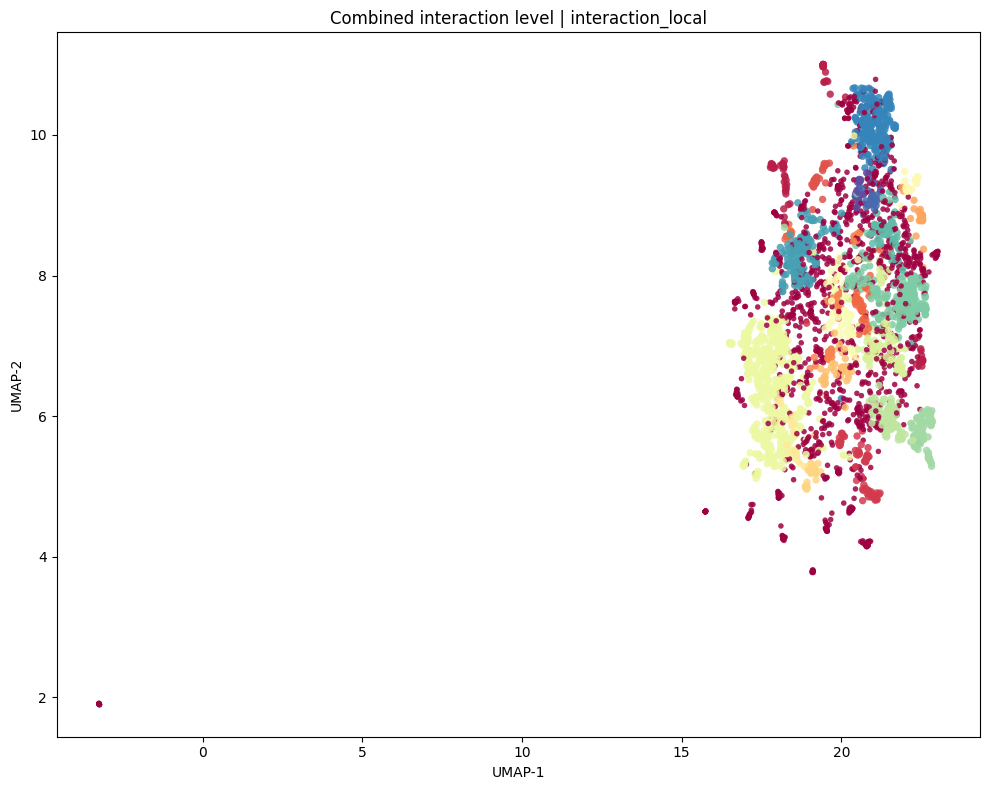

Output()

[20:29:35] Topic names generated.                                                                       ]8;id=163080;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/analyzers/base.py\base.py]8;;\:]8;id=47267;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/analyzers/base.py#217\217]8;;\

Output()

[20:31:41] Topic descriptions generated.                                                                ]8;id=640343;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/analyzers/base.py\base.py]8;;\:]8;id=138592;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/analyzers/base.py#224\224]8;;\

/Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:265: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(


...

[20:32:15] Dimensionality reduction done.                                                            ]8;id=363173;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=357207;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#464\464]8;;\

           Clustering done.                                                                          ]8;id=849661;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=834907;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#467\467]8;;\

           Parameter estimation done.                                                                ]8;id=834655;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=122039;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#486\486]8;;\

           Model fitting done.                                                                       ]8;id=764442;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=328424;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#500\500]8;;\

/Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


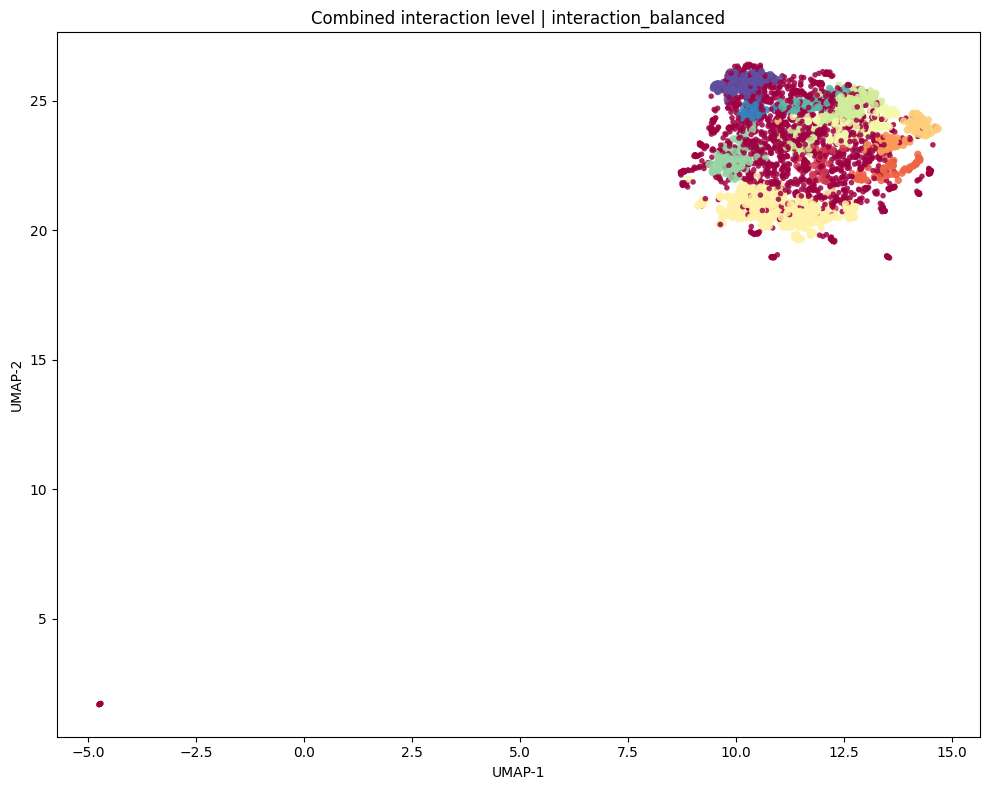

Output()

[20:33:10] Topic names generated.                                                                       ]8;id=781264;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/analyzers/base.py\base.py]8;;\:]8;id=216223;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/analyzers/base.py#217\217]8;;\

Output()

In [ ]:
DATASET_TO_RUN = "combined_interaction_level"
RUN_OPENAI_ANALYZER = True
SHOW_STATIC_PLOTS = True
SHOW_INTERACTIVE_PLOTS = True

selected_results = run_dataset_suite(
    dataset_name=DATASET_TO_RUN,
    run_openai=RUN_OPENAI_ANALYZER,
    show_static_plots=SHOW_STATIC_PLOTS,
    show_interactive_plots=SHOW_INTERACTIVE_PLOTS,
)
selected_results


In [ ]:
RUN_ALL_DATASETS = False
RUN_OPENAI_ANALYZER_FOR_SWEEP = True

if RUN_ALL_DATASETS:
    sweep_results = run_full_sweep(
        run_openai=RUN_OPENAI_ANALYZER_FOR_SWEEP,
        show_static_plots=False,
        show_interactive_plots=False,
    )
    display(sweep_results)
else:
    print("Set RUN_ALL_DATASETS = True to fit all datasets and all three tests per corpus profile.")
